IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [2]:
df = pd.read_csv("/content/events1.csv")
df.head()

,user_id,ga_session_id,country,device,type,item_id,date
0,2133,16909,US,mobile,purchase,94,2020-11-01 00:27:14
1,2133,16909,US,mobile,purchase,425,2020-11-01 00:27:14
2,5789,16908,SE,desktop,purchase,1,2020-11-01 01:44:44
3,5789,16908,SE,desktop,purchase,62,2020-11-01 01:44:44
4,5808,4267,US,mobile,add_to_cart,842,2020-11-01 03:06:29


DATA CLEANING


In [3]:
# Check null values
print(df.isnull().sum())

# Fill missing values
df.fillna(0, inplace=True)

user_id             0
ga_session_id       0
country          4555
device              0
type                0
item_id             0
date                0
dtype: int64


FEATURE ENGINEERING

In [4]:
df_grouped = df.groupby('user_id').agg({
    'ga_session_id': 'nunique',   # number of sessions
    'item_id': 'count',           # total interactions
    'date': 'nunique'             # active days
}).reset_index()

In [5]:
df_grouped.rename(columns={'ga_session_id': 'session_count'}, inplace=True)

In [6]:
df_grouped.rename(columns={'item_id': 'interaction_count'}, inplace=True)

In [7]:
df_grouped.rename(columns={'date': 'active_days'}, inplace=True)

In [8]:
device = df.groupby('user_id')['device'].agg(lambda x: x.mode()[0])
country = df.groupby('user_id')['country'].agg(lambda x: x.mode()[0])

df_grouped['device'] = device.values
df_grouped['country'] = country.values

In [9]:
df_grouped = pd.get_dummies(df_grouped, columns=['device', 'country'], drop_first=True)


FEATURE SELECTION

In [10]:
features = df_grouped[['session_count', 'interaction_count', 'active_days']]

FEATURE SCALING

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

FIND OPTIMAL CLUSTERS (ELBOW MWTHOD)

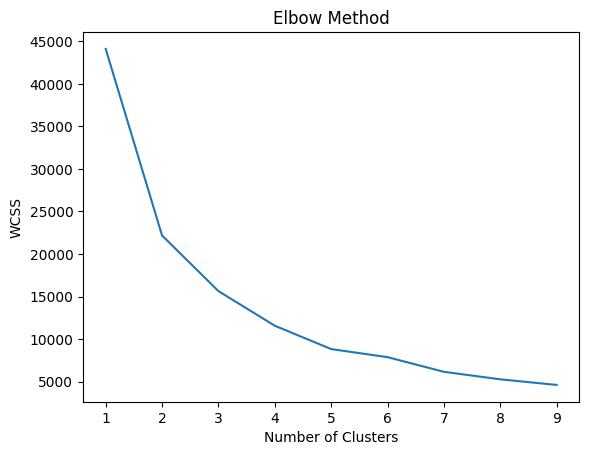

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

K-MEANS CLUSTERING


In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_grouped['Cluster'] = kmeans.fit_predict(X_scaled)

CLLUSTER SUMMARY

In [14]:
cluster_summary = df_grouped.groupby('Cluster').mean()
print(cluster_summary)

              user_id  session_count  interaction_count  active_days  \
Cluster                                                                
0        17115.345584       2.371914          70.613275     8.219967   
1        69126.374415       1.000000          24.513356     2.799740   
2        15773.209738       2.992509         483.666667    43.063670   
3        16617.495837       1.339500         202.014801    18.481036   

         device_mobile  device_tablet  country_AE  country_AL  country_AM  \
Cluster                                                                     
0             0.407570       0.017553    0.002194    0.000549    0.000549   
1             0.398005       0.022116    0.002255    0.000260    0.000000   
2             0.389513       0.029963    0.000000    0.000000    0.000000   
3             0.387604       0.017576    0.002775    0.000000    0.000000   

         country_AR  ...  country_TR  country_TT  country_TW  country_UA  \
Cluster              ...    

LABEL CLUSTERS


In [15]:
def label_cluster(x):
    if x == 0:
        return "High Value"
    elif x == 1:
        return "Active Users"
    elif x == 2:
        return "Occasional Users"
    else:
        return "Low Engagement"

df_grouped['Segment'] = df_grouped['Cluster'].apply(label_cluster)

VISUALISATION

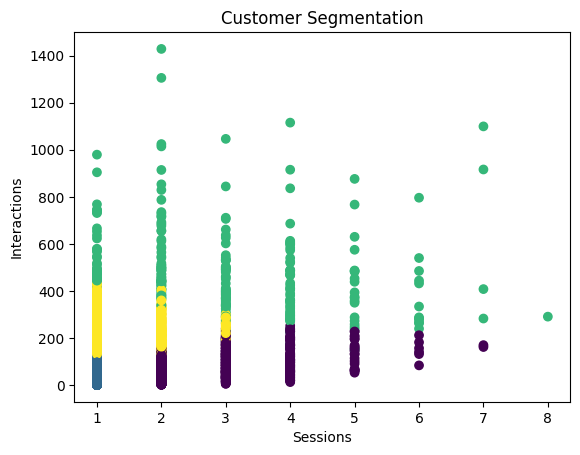

In [16]:
#SCATTER PLOT
plt.scatter(df_grouped['session_count'],
            df_grouped['interaction_count'],
            c=df_grouped['Cluster'])

plt.xlabel("Sessions")
plt.ylabel("Interactions")
plt.title("Customer Segmentation")
plt.show()

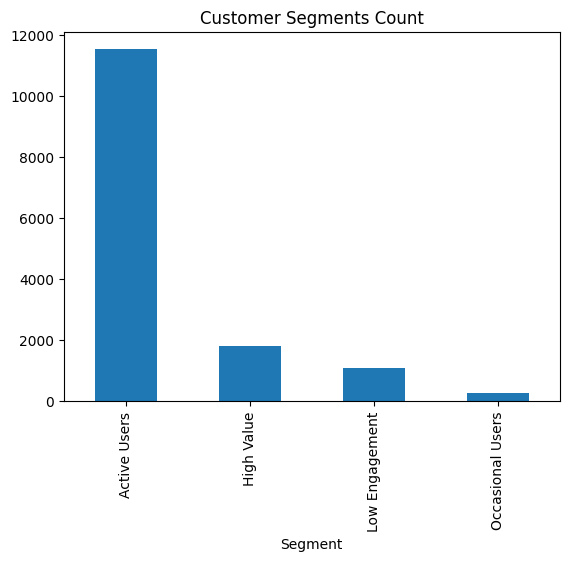

In [17]:
#SEGMENT DISTRIBUTION
df_grouped['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments Count")
plt.show()

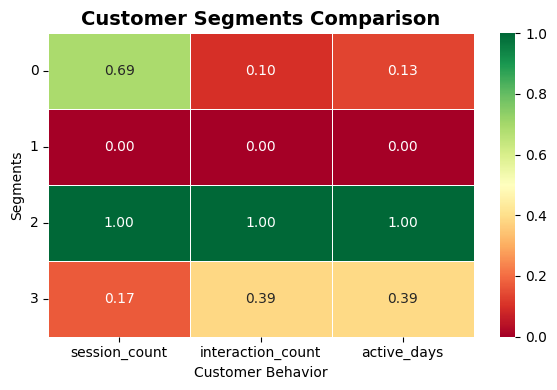

In [29]:
#HEATMAP
important_features = ['session_count', 'interaction_count', 'active_days']

summary = df_grouped.groupby('Cluster')[important_features].mean()

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
summary_scaled = pd.DataFrame(
    scaler.fit_transform(summary),
    columns=summary.columns,
    index=summary.index
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(summary_scaled,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",   # BEST for interpretation
            linewidths=0.5)

plt.title("Customer Segments Comparison", fontsize=14, weight='bold')
plt.xlabel("Customer Behavior")
plt.ylabel("Segments")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

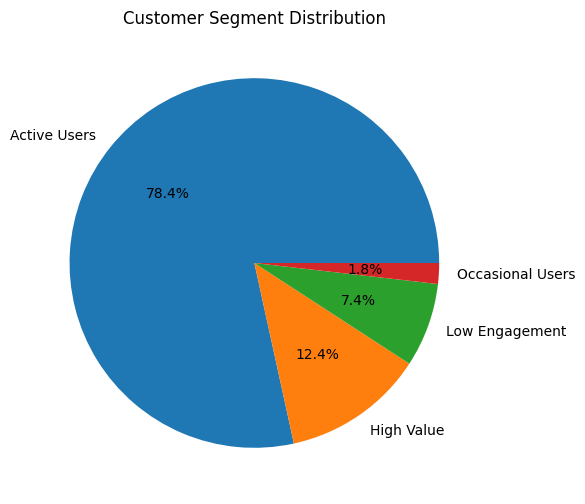

In [37]:
#PIE CHART (BUSINESS DISTRIBUTION)
df_grouped['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.show()

BUSINESS INSIGHTS

In [31]:
#CLUSTER-WISE BUSINESS SUMMARY
# Cluster-wise summary
insights = df_grouped.groupby('Segment').agg({
    'session_count': 'mean',
    'interaction_count': 'mean',
    'active_days': 'mean'
}).round(2)

print(insights)

                  session_count  interaction_count  active_days
Segment                                                        
Active Users               1.00              24.51         2.80
High Value                 2.37              70.61         8.22
Low Engagement             1.34             202.01        18.48
Occasional Users           2.99             483.67        43.06


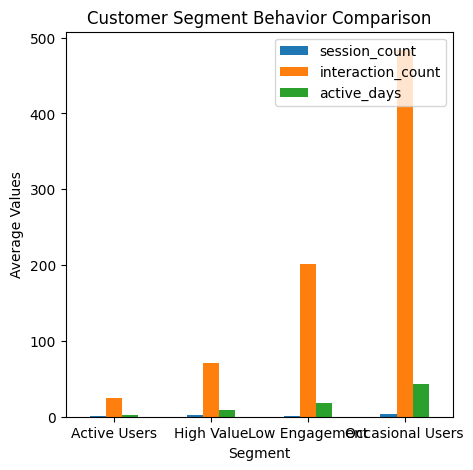

In [40]:
#VISUALIZE BUSINESS INSIGHTS
insights.plot(kind='bar', figsize=(5,5))

plt.title("Customer Segment Behavior Comparison")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.legend(loc='upper right')

plt.show()

In [34]:
#AUTOMATIC BUSINESS INTERPRETATION
for segment in insights.index:
    print(f"\n🔹 Segment: {segment}")

    if insights.loc[segment, 'session_count'] > insights['session_count'].mean():
        print("• High engagement (frequent visits)")
    else:
        print("• Low engagement")

    if insights.loc[segment, 'interaction_count'] > insights['interaction_count'].mean():
        print("• Highly active users")
    else:
        print("• Less interaction")


🔹 Segment: Active Users
• Low engagement
• Less interaction

🔹 Segment: High Value
• High engagement (frequent visits)
• Less interaction

🔹 Segment: Low Engagement
• Low engagement
• Highly active users

🔹 Segment: Occasional Users
• High engagement (frequent visits)
• Highly active users


In [35]:
#MARKETING STRATEGY
for segment in insights.index:
    print(f"\n🎯 Strategy for {segment}:")

    if segment == "High Value":
        print("• Offer loyalty rewards and premium services")

    elif segment == "Active Users":
        print("• Upsell products and personalized recommendations")

    elif segment == "Occasional":
        print("• Send email campaigns and discounts")

    elif segment == "Low Engagement":
        print("• Run awareness ads and re-engagement campaigns")


🎯 Strategy for Active Users:
• Upsell products and personalized recommendations

🎯 Strategy for High Value:
• Offer loyalty rewards and premium services

🎯 Strategy for Low Engagement:
• Run awareness ads and re-engagement campaigns

🎯 Strategy for Occasional Users:
